highest quality: 200080
highest quality: 200080
highest quality: 200080
highest quality: 200080


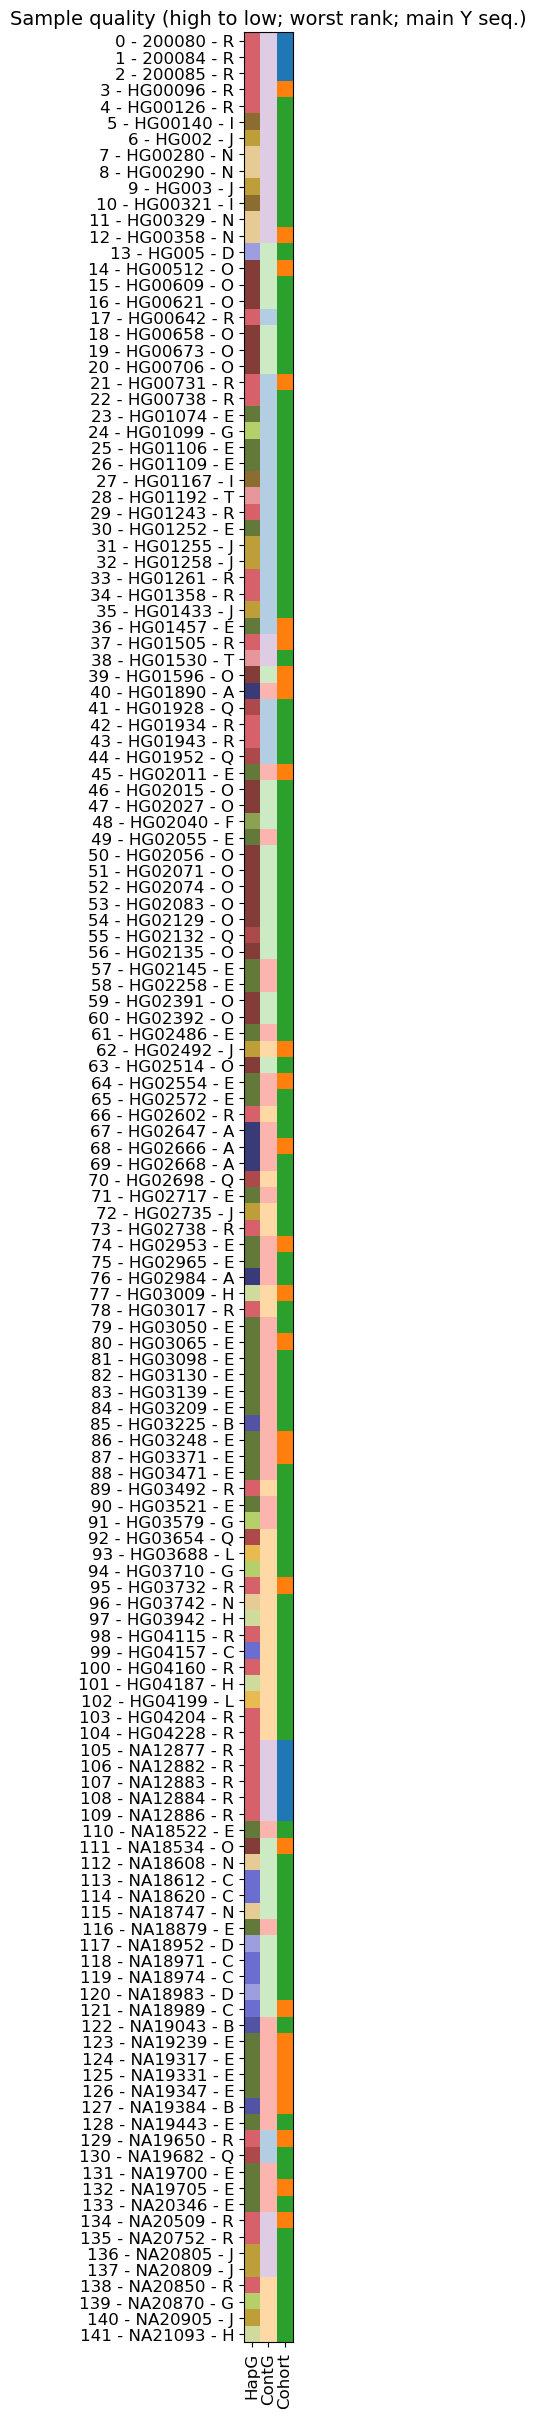

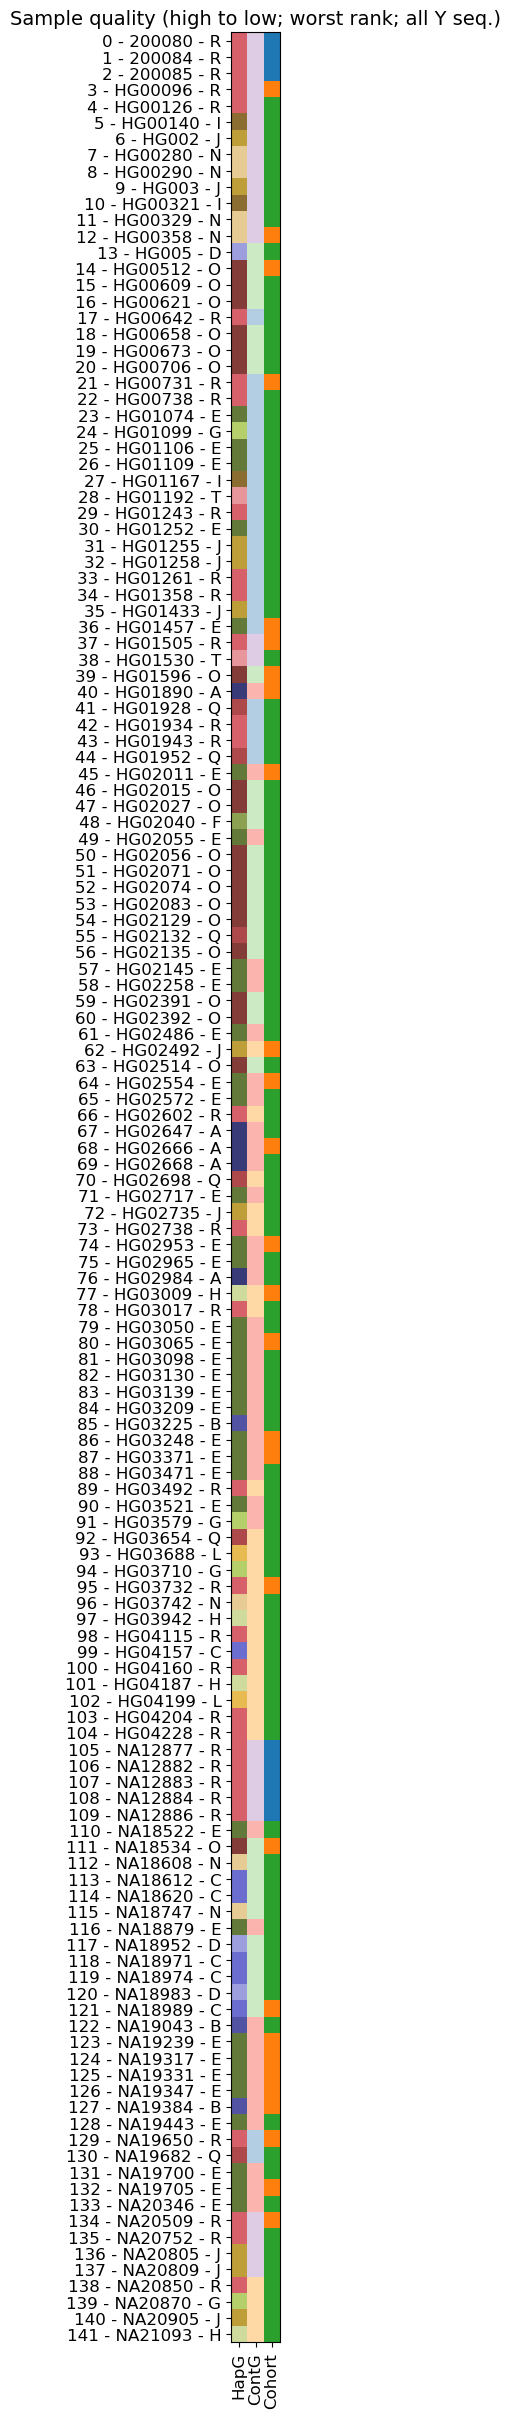

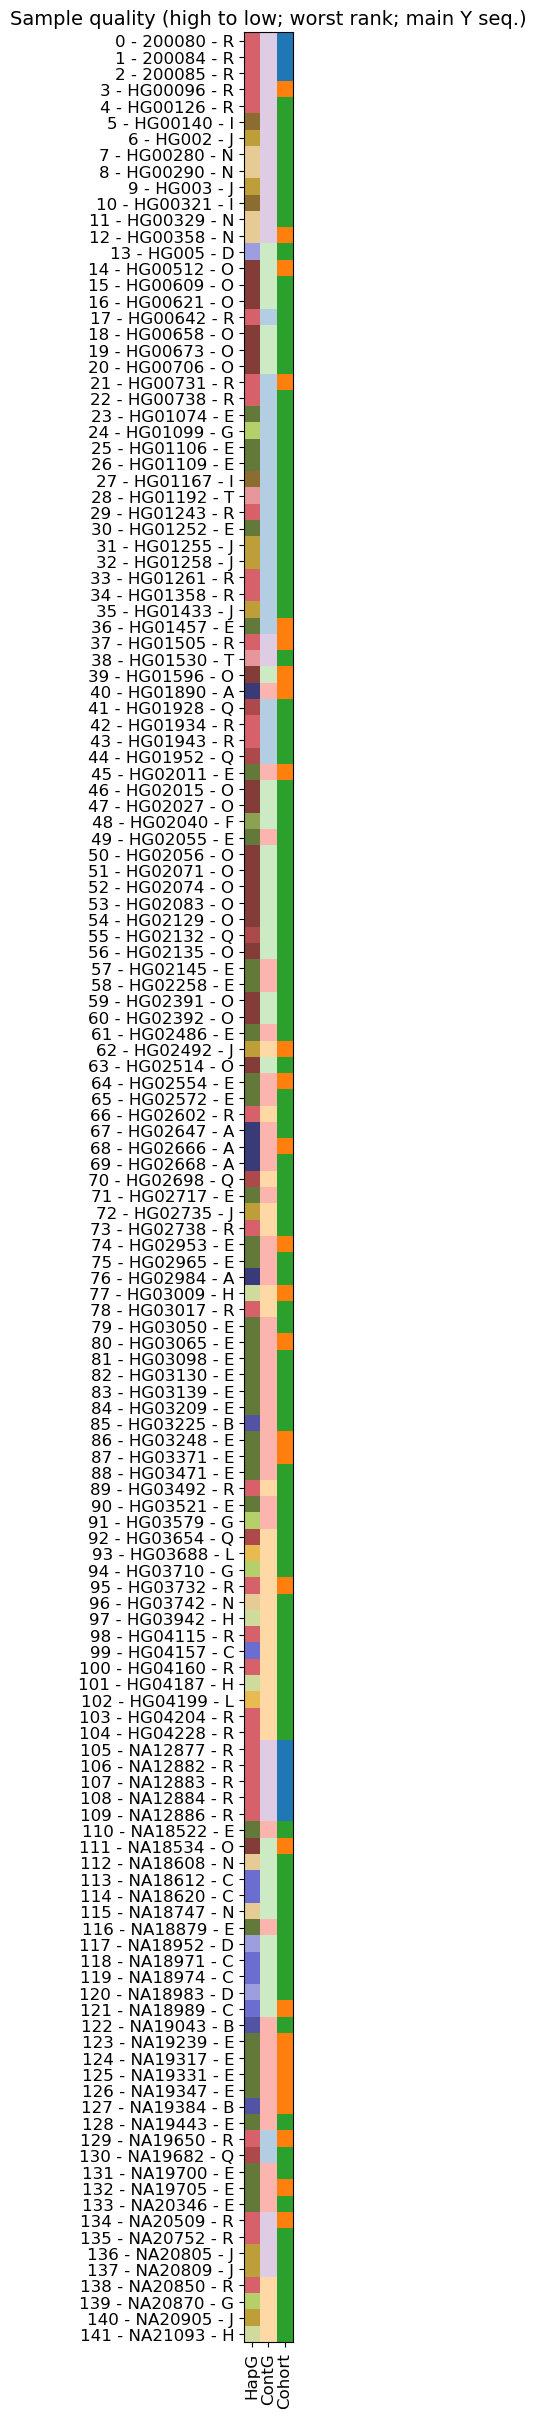

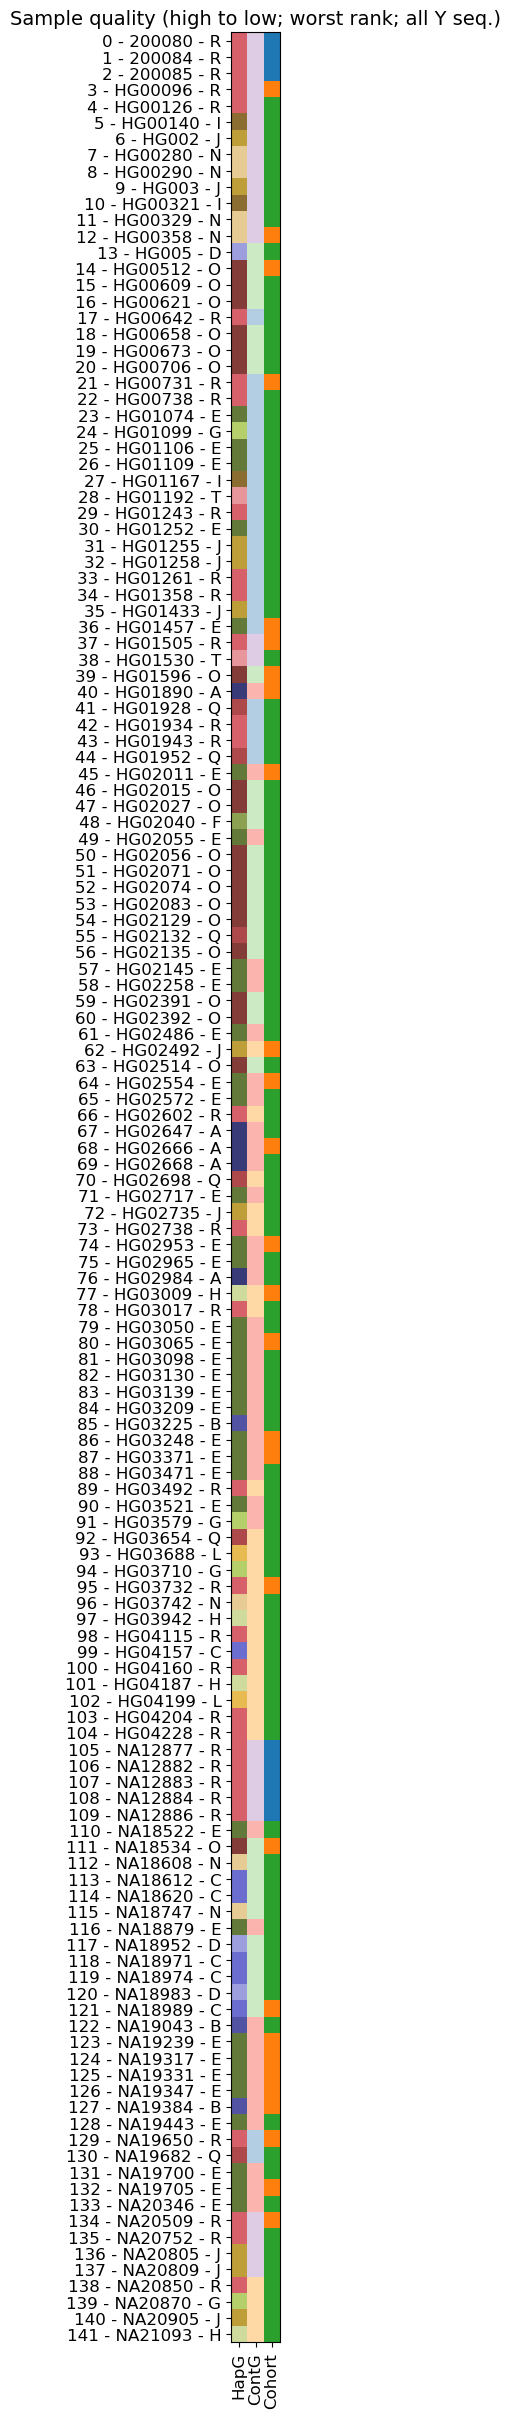

In [49]:
import pathlib as pl

cfg_nb = pl.Path("../../../load-config.ipynb").resolve(strict=True)
%run $cfg_nb

_NB_SESSION = __session__
NB_NAME = pl.Path(_NB_SESSION).name
NB_PATH = pl.Path(_NB_SESSION).parent
NB_REL_PATH = NB_PATH.relative_to(CONFIG["project_repo"]).joinpath(NB_NAME)

PLOT_ROOT = CONFIG["plot_root"].joinpath(NB_PATH.stem)
NB_CACHE_FOLDER = CONFIG["nb_cache_folder"]
DATA_ROOT = CONFIG["project_data"]

### NB-specific code

import re
import pandas as pd
import numpy as np
import collections as col

import matplotlib as mpl
import matplotlib.pyplot as plt


THIS_NB_DATA_ROOT = DATA_ROOT.joinpath("wf-data/region-labels/label_stats")


def simplify_color_block_labels(label):
    """This function is copied from the script
    PROJECT/codebase/postproc-region-labels/workflow/scripts/finalize_labels.py
    and MUST NOT be changed here.
    """
    colors = "(" + "|".join(["blue", "red", "green", "yellow", "gray"]) +")"
    mobj = re.search(colors, label)
    if mobj is None:
        return label
    s,e = mobj.span()
    color = label[s:e]
    qualifier = "(plus|IR[0-9])"
    mobj = re.search(qualifier, label)
    if mobj is not None:
        s, e = mobj.span()
        qual = label[s:e]
        new_label = f"{color}-{qual}"
    else:
        new_label = color
    return new_label


def compute_reference_annotation_stats(file_path, ref_label):

    df = pd.read_csv(file_path, sep="\t", header=0)
    df["length"] = df["end"] - df["start"]
    total_length = df["end"].max()
    df["base_label"] = df["seqclass"].apply(simplify_color_block_labels)
    # gen list of labels in chrom pos order
    label_order = []
    for row in df.itertuples():
        if row.base_label in label_order:
            continue
        label_order.append(row.base_label)
    agg = df.groupby(["#chrom", "base_label"])["length"].sum().reset_index(drop=False, inplace=False)
    agg["seq_length"] = total_length
    agg["pct_cov"] = (agg["length"] / agg["seq_length"] * 100).round(3)
    assert len(label_order) == df["base_label"].nunique()
    label_order.extend(["UNASSIGNED", "ERRBASE", "ERRSTRUCT", "NGAP"])
    return agg, label_order


def read_haplogroup_info():

    annot_file = CONFIG["project_repo"].joinpath("annotation", "norm", "samples_hg.tsv")
    df = pd.read_csv(annot_file, sep="\t", header=0)
    df["hg_char"] = df["hg_short"].str.slice(0,1)

    cmap_hg = mpl.colormaps["tab20b"].colors
    hg_colors = dict(
        (hgroup, color) for hgroup, color in zip(sorted(df["hg_char"].unique()), cmap_hg)
    )

    cmap_cg = mpl.colormaps["Pastel1"].colors
    cg_colors = dict(
        (cgroup, color) for cgroup, color in zip(sorted(df["continental_group"].unique()), cmap_cg)
    )

    cmap_ch = mpl.colormaps["tab10"].colors
    ch_colors = dict(
        (cohort, color) for cohort, color in zip(sorted(df["cohort"].unique()), cmap_ch)
    )
    
    df.set_index("sample", inplace=True)
    return df, hg_colors, cg_colors, ch_colors

hg38_stats, hg38_order = compute_reference_annotation_stats(
    CONFIG["project_repo"].joinpath("annotation", "norm", "GRCh38-Y_regions_repeat-details.bed"),
    "hg38"
)
t2t_stats, t2t_order = compute_reference_annotation_stats(
    CONFIG["project_repo"].joinpath("annotation", "norm", "HG002-Y_T2Tv2_regions_repeat-details.bed"),
    "t2tv2"
)

ref_info = {
    "hg38_stats": hg38_stats,
    "hg38_order": hg38_order,
    "t2tv2_stats": t2t_stats,
    "t2tv2_order": t2t_order
}

annot_state = "DRAFT"
refs = ["t2tv2", "hg38"]

subset_select = [
    ("main", 0, "seq_pct_cov"),
    ("all", -1, "total_pct_cov")
]


smp_lut, hg_colors, cg_colors, ch_colors = read_haplogroup_info()


negative_labels = ["NGAP", "UNASSIGNED", "ERRSTRUCT", "ERRBASE"]

for ref in refs:
    collect_values = {
        "main": [],
        "all": []
    }
    data_file = f"{ref}.label-dist-stats.tsv"
    df = pd.read_csv(THIS_NB_DATA_ROOT.joinpath(data_file), sep="\t", header=0)
    df = df.loc[df["name"].isin(negative_labels), :].copy()

    for seq_type, _, stat_column in subset_select:
        if seq_type == "all":
            subdata = df.copy()
        else:
            subdata = df.loc[df["seq_type"] == seq_type, :].copy()
        samples = sorted(subdata["sample"].unique())
        agg = subdata.groupby(["sample", "name"])[stat_column].sum()
        rank_df = []
        for l in negative_labels:
            label_values = []
            for s in samples:
                try:
                    value = agg.loc[(s, l)]
                except KeyError:
                    value = 0
                label_values.append(value)
            rank_df.append(label_values)
        rank_df = pd.DataFrame(
            rank_df,
            index=negative_labels,
            columns=samples
        )
        sample_ranks = rank_df.rank(axis=1, method="min")
        sample_ranks = sample_ranks.max(axis=0)
        
        grid = np.zeros((sample_ranks.size, 3, 3), dtype=float)
        y_labels = []

        for row_idx, (sample, _) in enumerate(sample_ranks.items()):
            if row_idx == 0:
                print(f"highest quality: {sample}")
            
            hg = smp_lut.loc[sample, "hg_char"]
            hgc = hg_colors[hg]
            cg = smp_lut.loc[sample, "continental_group"]
            cgc = cg_colors[cg]
            ch = smp_lut.loc[sample, "cohort"]
            chc = ch_colors[ch]

            y_labels.append(f"{row_idx} - {sample} - {hg}")

            grid[row_idx, 0, :] = hgc
            grid[row_idx, 1, :] = cgc
            grid[row_idx, 2, :] = chc

        fig, ax = plt.subplots(figsize=(30,30))

        ax.imshow(grid)
        ax.set_yticks(np.arange(0, sample_ranks.size))
        ax.set_yticklabels(y_labels, fontsize=12)

        ax.set_xticks([0,1,2])
        ax.set_xticklabels(["HapG", "ContG", "Cohort"], fontsize=12, rotation=90)

        ax.set_title(f"Sample quality (high to low; worst rank; {seq_type} Y seq.)", fontsize=14)

        PLOT_ROOT.mkdir(exist_ok=True, parents=True)
        outfile = PLOT_ROOT.joinpath(f"{ref}.{seq_type}.sample-ranking-colormap.png")
        plt.savefig(outfile, dpi=150, bbox_inches="tight")
        
        
